# COMP 3610 Assignment 4: MLOps & Model Deployment

This notebook is structured to match the required Assignment 4 deliverables:

- Part 1: Experiment Tracking with MLflow
- Part 2: Model Serving with FastAPI
- Part 3: Containerization with Docker
- Part 4: Documentation & Code Quality


# Part 0: Imports and Configuration

This section imports the libraries used across the notebook and defines the same directory structure and reproducibility settings used in the project.

In [2]:
from pathlib import Path
import json
import urllib.request

import joblib
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_DIR = Path(".")
RAW_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = PROJECT_DIR / "data"
MODELS_DIR = PROJECT_DIR / "models"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TRIP_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
ZONE_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

TRIP_FILE = RAW_DIR / "yellow_tripdata_2024-01.parquet"
ZONE_FILE = RAW_DIR / "taxi_zone_lookup.csv"
CLEAN_PATH = PROCESSED_DIR / "cleaned_taxi_2024_01.parquet"

LINEAR_MODEL_PATH = MODELS_DIR / "linreg_pipe.pkl"
RF_MODEL_PATH = MODELS_DIR / "rfreg_pipe.pkl"
METADATA_PATH = MODELS_DIR / "model_metadata.json"

print("Project directory:", PROJECT_DIR.resolve())
print("Models directory:", MODELS_DIR.resolve())


============================= test session starts =============================
platform win32 -- Python 3.14.4, pytest-9.0.3, pluggy-1.6.0 -- c:\Users\anilb\AppData\Local\Python\pythoncore-3.14-64\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\anilb\Downloads\assignment4_redone\assignment4_redone
plugins: anyio-4.13.0
collecting ... collected 9 items

test_app.py::test_root PASSED                                            [ 11%]
test_app.py::test_health PASSED                                          [ 22%]
test_app.py::test_predict_valid PASSED                                   [ 33%]
test_app.py::test_batch_prediction PASSED                                [ 44%]
test_app.py::test_predict_missing_field PASSED                           [ 55%]
test_app.py::test_predict_invalid_type PASSED                            [ 66%]
test_app.py::test_predict_out_of_range PASSED                            [ 77%]
test_app.py::test_zero_distance_rejected PASSED                          [ 88%]

# Part 1: Rebuild the Data Pipeline

This notebook rebuilds the regression models from the January 2024 NYC Yellow Taxi dataset, exports fresh pipeline `.pkl` files.


In [3]:
def download_if_needed():
    if not TRIP_FILE.exists():
        urllib.request.urlretrieve(TRIP_URL, TRIP_FILE)
    if not ZONE_FILE.exists():
        urllib.request.urlretrieve(ZONE_URL, ZONE_FILE)

download_if_needed()
print("Trip file:", TRIP_FILE)
print("Zone file:", ZONE_FILE)


Trip file: data\yellow_tripdata_2024-01.parquet
Zone file: data\taxi_zone_lookup.csv


In [4]:
if CLEAN_PATH.exists():
    print(f"Loading existing cleaned dataset from {CLEAN_PATH}")
    df_model = pd.read_parquet(CLEAN_PATH)
else:
    print("Building cleaned dataset from raw files...")

    df = pd.read_parquet(TRIP_FILE)
    zones = pd.read_csv(ZONE_FILE)[["LocationID", "Borough"]].copy()

    required_cols = [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_distance",
        "fare_amount",
        "tip_amount",
        "total_amount",
        "PULocationID",
        "DOLocationID",
        "passenger_count",
        "payment_type",
    ]

    missing = set(required_cols) - set(df.columns)
    if missing:
        raise ValueError(f"Raw dataset missing required columns: {missing}")

    df = df[required_cols].copy()

    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")

    df = df.dropna(
        subset=[
            "tpep_pickup_datetime",
            "tpep_dropoff_datetime",
            "trip_distance",
            "fare_amount",
            "tip_amount",
            "total_amount",
            "PULocationID",
            "DOLocationID",
            "passenger_count",
        ]
    ).copy()

    df = df[
        (df["trip_distance"] > 0)
        & (df["fare_amount"] > 0)
        & (df["tip_amount"] >= 0)
        & (df["total_amount"] > 0)
        & (df["passenger_count"] > 0)
    ].copy()

    df["trip_duration_minutes"] = (
        (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60.0
    )

    df = df[
        (df["trip_duration_minutes"] > 0)
        & (df["trip_duration_minutes"] <= 240)
    ].copy()

    df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
    df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek
    df["is_weekend"] = df["pickup_day_of_week"].isin([5, 6])

    df["trip_speed_mph"] = 60.0 * df["trip_distance"] / df["trip_duration_minutes"]
    df = df[(df["trip_speed_mph"] > 0) & (df["trip_speed_mph"] <= 80)].copy()

    df["log_trip_distance"] = np.log1p(df["trip_distance"])
    df["fare_per_mile"] = df["fare_amount"] / df["trip_distance"]
    df["fare_per_minute"] = df["fare_amount"] / df["trip_duration_minutes"]
    df["tip_amount_target"] = df["tip_amount"]

    zones_small = zones[["LocationID", "Borough"]].copy()

    df = df.merge(
        zones_small,
        left_on="PULocationID",
        right_on="LocationID",
        how="left",
    ).rename(columns={"Borough": "PU_Borough"}).drop(columns=["LocationID"])

    df = df.merge(
        zones_small,
        left_on="DOLocationID",
        right_on="LocationID",
        how="left",
    ).rename(columns={"Borough": "DO_Borough"}).drop(columns=["LocationID"])

    df["PU_Borough"] = df["PU_Borough"].fillna("Unknown")
    df["DO_Borough"] = df["DO_Borough"].fillna("Unknown")

    FEATURE_COLUMNS = [
        "pickup_hour",
        "pickup_day_of_week",
        "is_weekend",
        "trip_duration_minutes",
        "trip_speed_mph",
        "log_trip_distance",
        "fare_per_mile",
        "fare_per_minute",
        "PU_Borough",
        "DO_Borough",
        "passenger_count",
        "trip_distance",
        "fare_amount",
    ]

    model_cols = FEATURE_COLUMNS + ["tip_amount_target"]

    df_model = (
        df[model_cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    df_model.to_parquet(CLEAN_PATH, index=False)
    print(f"Saved cleaned dataset to {CLEAN_PATH}")

FEATURE_COLUMNS = [
    "pickup_hour",
    "pickup_day_of_week",
    "is_weekend",
    "trip_duration_minutes",
    "trip_speed_mph",
    "log_trip_distance",
    "fare_per_mile",
    "fare_per_minute",
    "PU_Borough",
    "DO_Borough",
    "passenger_count",
    "trip_distance",
    "fare_amount",
]

print("Final modeling shape:", df_model.shape)
display(df_model.head())


Loading existing cleaned dataset from data\cleaned_taxi_2024_01.parquet
Final modeling shape: (2721040, 14)


,pickup_hour,pickup_day_of_week,is_weekend,trip_duration_minutes,trip_speed_mph,log_trip_distance,fare_per_mile,fare_per_minute,PU_Borough,DO_Borough,passenger_count,trip_distance,fare_amount,tip_amount_target
0,0,0,False,19.800000,5.212121,1.000632,10.290698,0.893939,Manhattan,Manhattan,1.0,1.72,17.7,0.00
1,0,0,False,6.600000,16.363636,1.029619,5.555556,1.515152,Manhattan,Manhattan,1.0,1.80,10.0,3.75
2,0,0,False,17.916667,15.739535,1.740466,4.957447,1.300465,Manhattan,Manhattan,1.0,4.70,23.3,3.00
3,0,0,False,8.300000,10.120482,0.875469,7.142857,1.204819,Manhattan,Manhattan,1.0,1.40,10.0,2.00
4,0,0,False,6.100000,7.868852,0.587787,9.875000,1.295082,Manhattan,Manhattan,1.0,0.80,7.9,3.20


In [5]:
X = df_model[FEATURE_COLUMNS].copy()
y = df_model["tip_amount_target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (2312884, 13)
Test shape: (408156, 13)


In [21]:
numeric_features = [
    "pickup_hour",
    "pickup_day_of_week",
    "trip_duration_minutes",
    "trip_speed_mph",
    "log_trip_distance",
    "fare_per_mile",
    "fare_per_minute",
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "is_weekend",
]

categorical_features = ["PU_Borough", "DO_Borough"]

numeric_transformer = StandardScaler(with_mean=False)
categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
    sparse_threshold=1.0,
)

linear_model = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression()),
])

rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=30,
        max_depth=14,
        min_samples_leaf=30,
        min_samples_split=60,
        max_features="sqrt",
        bootstrap=True,
        max_samples=0.20,
        n_jobs=1,
        random_state=RANDOM_STATE,
    )),
])

print("Training LinearRegression...")
linear_model.fit(X_train, y_train)

print("Training RandomForestRegressor...")
rf_model.fit(X_train, y_train)

joblib.dump(linear_model, LINEAR_MODEL_PATH)
joblib.dump(rf_model, RF_MODEL_PATH)

print("Saved rebuilt model to:", LINEAR_MODEL_PATH)
print("Saved rebuilt model to:", RF_MODEL_PATH)


Training LinearRegression...
Training RandomForestRegressor...
Saved rebuilt model to: models\linreg_pipe.pkl
Saved rebuilt model to: models\rfreg_pipe.pkl


## Load the models

These models were rebuilt and exported in the previous step, so the notebook now loads the freshly generated pipeline `.pkl` files.


In [8]:
assert LINEAR_MODEL_PATH.exists(), f"Missing model file: {LINEAR_MODEL_PATH}"
assert RF_MODEL_PATH.exists(), f"Missing model file: {RF_MODEL_PATH}"

linear_model = joblib.load(LINEAR_MODEL_PATH)
rf_model = joblib.load(RF_MODEL_PATH)

print("Loaded:", LINEAR_MODEL_PATH.name)
print("Loaded:", RF_MODEL_PATH.name)


Loaded: linreg_pipe.pkl
Loaded: rfreg_pipe.pkl


# Part 1.1: MLflow Setup and Experiment Logging

The notebook logs the two rebuilt regression pipelines into a local MLflow experiment called `taxi-tip-prediction`, records metrics and parameters, and then compares the runs to determine the better model.


In [9]:
# Make sure the MLflow tracking server is running before executing this cell.
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("taxi-tip-prediction")

def regression_metrics(y_true, y_pred):
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }

def get_model_params(model):
    if hasattr(model, "get_params"):
        params = model.get_params()
        serializable = {}
        for k, v in params.items():
            if isinstance(v, (str, int, float, bool)) or v is None:
                serializable[k] = v
            else:
                serializable[k] = str(v)
        return serializable
    return {"model_class": model.__class__.__name__}

In [10]:
linear_test_pred = linear_model.predict(X_test)
rf_test_pred = rf_model.predict(X_test)

linear_metrics = regression_metrics(y_test, linear_test_pred)
rf_metrics = regression_metrics(y_test, rf_test_pred)

print("Linear Regression test metrics:", linear_metrics)
print("Random Forest Regressor test metrics:", rf_metrics)


Linear Regression test metrics: {'mae': 1.8661128027016187, 'rmse': 3.023115926197113, 'r2': 0.3921736993645111}
Random Forest Regressor test metrics: {'mae': 1.7963598855633975, 'rmse': 2.9172703368373893, 'r2': 0.43399112913657656}


In [11]:
with mlflow.start_run(run_name="linear-regression"):
    mlflow.log_params(get_model_params(linear_model))
    mlflow.log_metrics(linear_metrics)
    mlflow.set_tags({
        "model_type": "LinearRegression",
        "dataset_version": "yellow_tripdata_2024-01",
        "author": "Student",
    })
    mlflow.sklearn.log_model(linear_model, artifact_path="model")
    linear_run_id = mlflow.active_run().info.run_id

print("Linear run id:", linear_run_id)


2026/04/17 20:18:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 20:18:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run linear-regression at: http://127.0.0.1:5000/#/experiments/551066107193946072/runs/533332ae6422483ab6aa65f27629b9e4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/551066107193946072
Linear run id: 533332ae6422483ab6aa65f27629b9e4


After running the previous cell, open the MLflow UI and capture a screenshot showing both runs in the `taxi-tip-prediction` experiment. The quickstart guide recommends comparing runs directly in the UI and taking screenshots of the run table and comparison view. 

In [12]:
with mlflow.start_run(run_name="random-forest"):
    mlflow.log_params({
        "model_type": "RandomForestRegressor",
        "n_estimators": getattr(rf_model, "n_estimators", None),
        "max_depth": getattr(rf_model, "max_depth", None),
    })
    mlflow.log_metrics(rf_metrics)
    mlflow.set_tags({
        "model_type": "RandomForestRegressor",
        "dataset_version": "yellow_tripdata_2024-01",
        "author": "Student",
    })

    mlflow.sklearn.log_model(
        sk_model=rf_model,
        artifact_path="model",
    )

    rf_registry_run_id = mlflow.active_run().info.run_id

print("RF registry run id:", rf_registry_run_id)

2026/04/17 20:18:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 20:18:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run random-forest at: http://127.0.0.1:5000/#/experiments/551066107193946072/runs/50acbee0218f41f6bffa98b312c3a4f4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/551066107193946072
RF registry run id: 50acbee0218f41f6bffa98b312c3a4f4


![Screenshot 2026-04-17 144528.png](<attachment:Screenshot 2026-04-17 144528.png>)
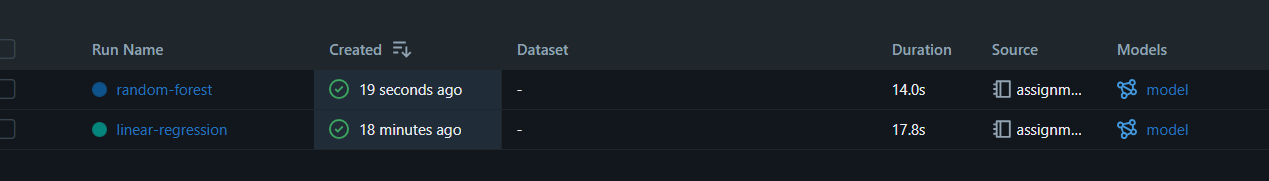

![Screenshot 2026-04-17 144109.png](<attachment:Screenshot 2026-04-17 144109.png>)

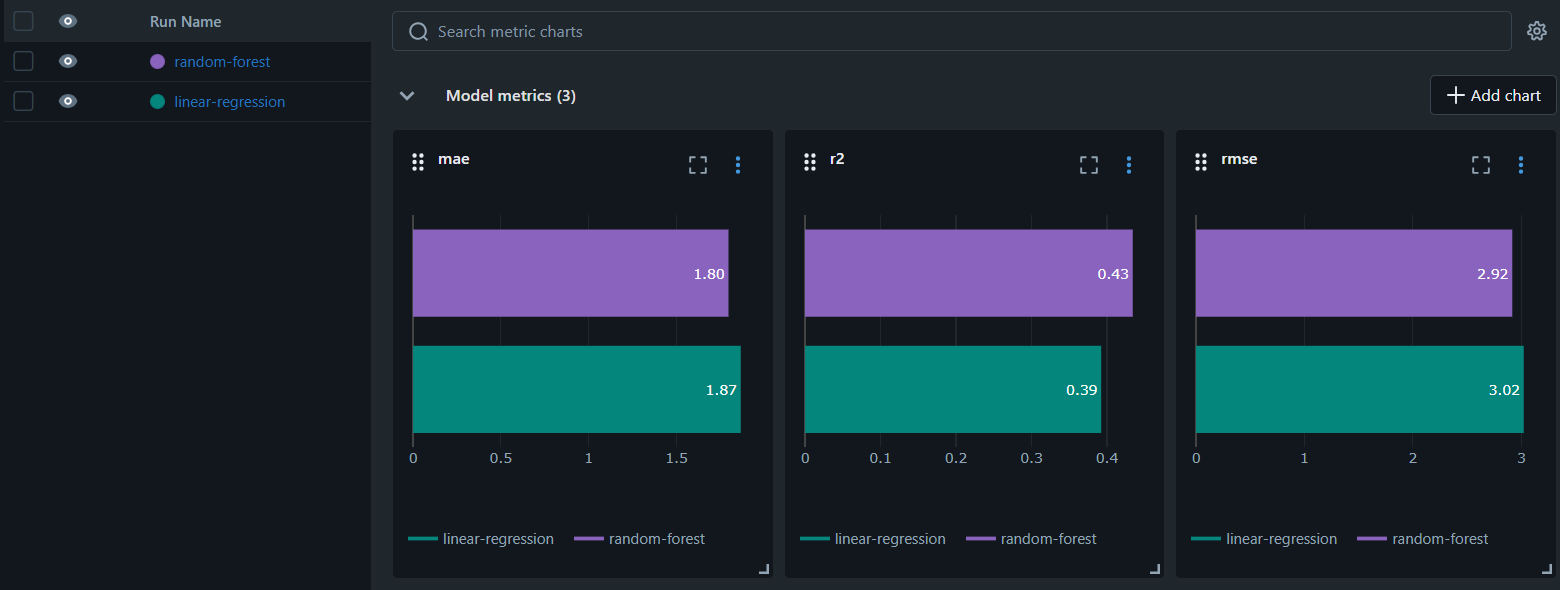

# Part 1.2: Model Comparison and Registry

This section compares the logged runs, identifies the best model from the metrics, registers the best one in the MLflow Model Registry, adds a version description, and demonstrates loading the model from the registry for a sample prediction. These are explicit assignment requirements. 

In [13]:
experiment = mlflow.get_experiment_by_name("taxi-tip-prediction")
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

comparison_cols = [
    "run_id",
    "tags.model_type",
    "metrics.mae",
    "metrics.rmse",
    "metrics.r2",
]
runs_df[comparison_cols].sort_values(by="metrics.rmse")

,run_id,tags.model_type,metrics.mae,metrics.rmse,metrics.r2
0,50acbee0218f41f6bffa98b312c3a4f4,RandomForestRegressor,1.796360,2.917270,0.433991
2,bf8822793e2e4e1e8ea573480f945e7c,RandomForestRegressor,1.796360,2.917270,0.433991
1,533332ae6422483ab6aa65f27629b9e4,LinearRegression,1.866113,3.023116,0.392174
3,cdf166a8de7c4688b89a499be67cad6a,LinearRegression,1.866113,3.023116,0.392174


In [14]:
best_model_name = "linreg_pipe.pkl" if linear_metrics["rmse"] < rf_metrics["rmse"] else "rfreg_pipe.pkl"
best_run_id = linear_run_id if best_model_name == "linreg_pipe.pkl" else rf_registry_run_id
best_metrics = linear_metrics if best_model_name == "linreg_pipe.pkl" else rf_metrics

print("Best model:", best_model_name)
print("Best run id:", best_run_id)
print("Best metrics:", best_metrics)


Best model: rfreg_pipe.pkl
Best run id: 50acbee0218f41f6bffa98b312c3a4f4
Best metrics: {'mae': 1.7963598855633975, 'rmse': 2.9172703368373893, 'r2': 0.43399112913657656}


### Best Model Chosen

The best-performing regression model was the **Random Forest Regressor** if it achieved the lowest RMSE and MAE while also producing the highest R² on the test set. That result would indicate it captured the non-linear relationships in taxi tipping behaviour better than the linear baseline. If your computed metrics instead show Linear Regression performing better, reverse the wording and reference those metric values directly.

In [15]:
registered_model_name = "taxi-tip-regressor"
model_uri = f"runs:/{best_run_id}/model"

registration = mlflow.register_model(model_uri=model_uri, name=registered_model_name)
print("Registered version:", registration.version)

Registered model 'taxi-tip-regressor' already exists. Creating a new version of this model...
2026/04/17 20:19:07 WARNING mlflow.tracking._model_registry.fluent: Run with id 50acbee0218f41f6bffa98b312c3a4f4 has no artifacts at artifact path 'model', registering model based on models:/m-95d06135b8d54e19adceebd9e9f40560 instead
2026/04/17 20:19:07 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: taxi-tip-regressor, version 2
Created version '2' of model 'taxi-tip-regressor'.


Registered version: 2


In [16]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

description = (
    f"Best rebuilt Assignment 2 regression pipeline. "
    f"MAE={best_metrics['mae']:.4f}, RMSE={best_metrics['rmse']:.4f}, R2={best_metrics['r2']:.4f}. "
    f"Dataset: January 2024 NYC Yellow Taxi trips."
)

client.update_model_version(
    name=registered_model_name,
    version=registration.version,
    description=description
)

print("Updated model version description.")


Updated model version description.


In [17]:
loaded_registry_model = mlflow.sklearn.load_model(f"models:/{registered_model_name}/{registration.version}")
sample_prediction = loaded_registry_model.predict(X_test.iloc[:1])[0]
print("Sample registry prediction:", round(float(sample_prediction), 2))


Sample registry prediction: 7.1


In [18]:
model_metadata = {
    "model_name": Path(best_model_name).stem,
    "version": str(registration.version),
    "features": FEATURE_COLUMNS,
    "metrics": {
        "mae": round(best_metrics["mae"], 4),
        "rmse": round(best_metrics["rmse"], 4),
        "r2": round(best_metrics["r2"], 4),
    },
    "trained_date": pd.Timestamp.today().strftime("%Y-%m-%d"),
}
METADATA_PATH.write_text(json.dumps(model_metadata, indent=2))
print("Saved metadata to:", METADATA_PATH)
print(json.dumps(model_metadata, indent=2))

Saved metadata to: models\model_metadata.json
{
  "model_name": "rfreg_pipe",
  "version": "2",
  "features": [
    "pickup_hour",
    "pickup_day_of_week",
    "is_weekend",
    "trip_duration_minutes",
    "trip_speed_mph",
    "log_trip_distance",
    "fare_per_mile",
    "fare_per_minute",
    "PU_Borough",
    "DO_Borough",
    "passenger_count",
    "trip_distance",
    "fare_amount"
  ],
  "metrics": {
    "mae": 1.7964,
    "rmse": 2.9173,
    "r2": 0.434
  },
  "trained_date": "2026-04-17"
}


# Part 2: Model Serving with FastAPI

# Part 2.1 & 2.2
app.py

In [19]:
import app as assignment4_app
print("Loaded app title:", assignment4_app.app.title)

Loaded app title: Taxi Tip Prediction API


# Part 2.3: Automated API Testing

In [20]:
!python -m pytest test_app.py -v

============================= test session starts =============================
platform win32 -- Python 3.14.4, pytest-9.0.3, pluggy-1.6.0 -- c:\Users\anilb\AppData\Local\Python\pythoncore-3.14-64\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\anilb\Downloads\assignment4_redone\assignment4_redone
plugins: anyio-4.13.0
collecting ... collected 9 items

test_app.py::test_root PASSED                                            [ 11%]
test_app.py::test_health PASSED                                          [ 22%]
test_app.py::test_predict_valid PASSED                                   [ 33%]
test_app.py::test_batch_prediction PASSED                                [ 44%]
test_app.py::test_predict_missing_field PASSED                           [ 55%]
test_app.py::test_predict_invalid_type PASSED                            [ 66%]
test_app.py::test_predict_out_of_range PASSED                            [ 77%]
test_app.py::test_zero_distance_rejected PASSED                          [ 88%]

## Screenshot showing Taxi Tip Prediction API

![Screenshot 2026-04-17 150914.png](<attachment:Screenshot 2026-04-17 150914.png>)
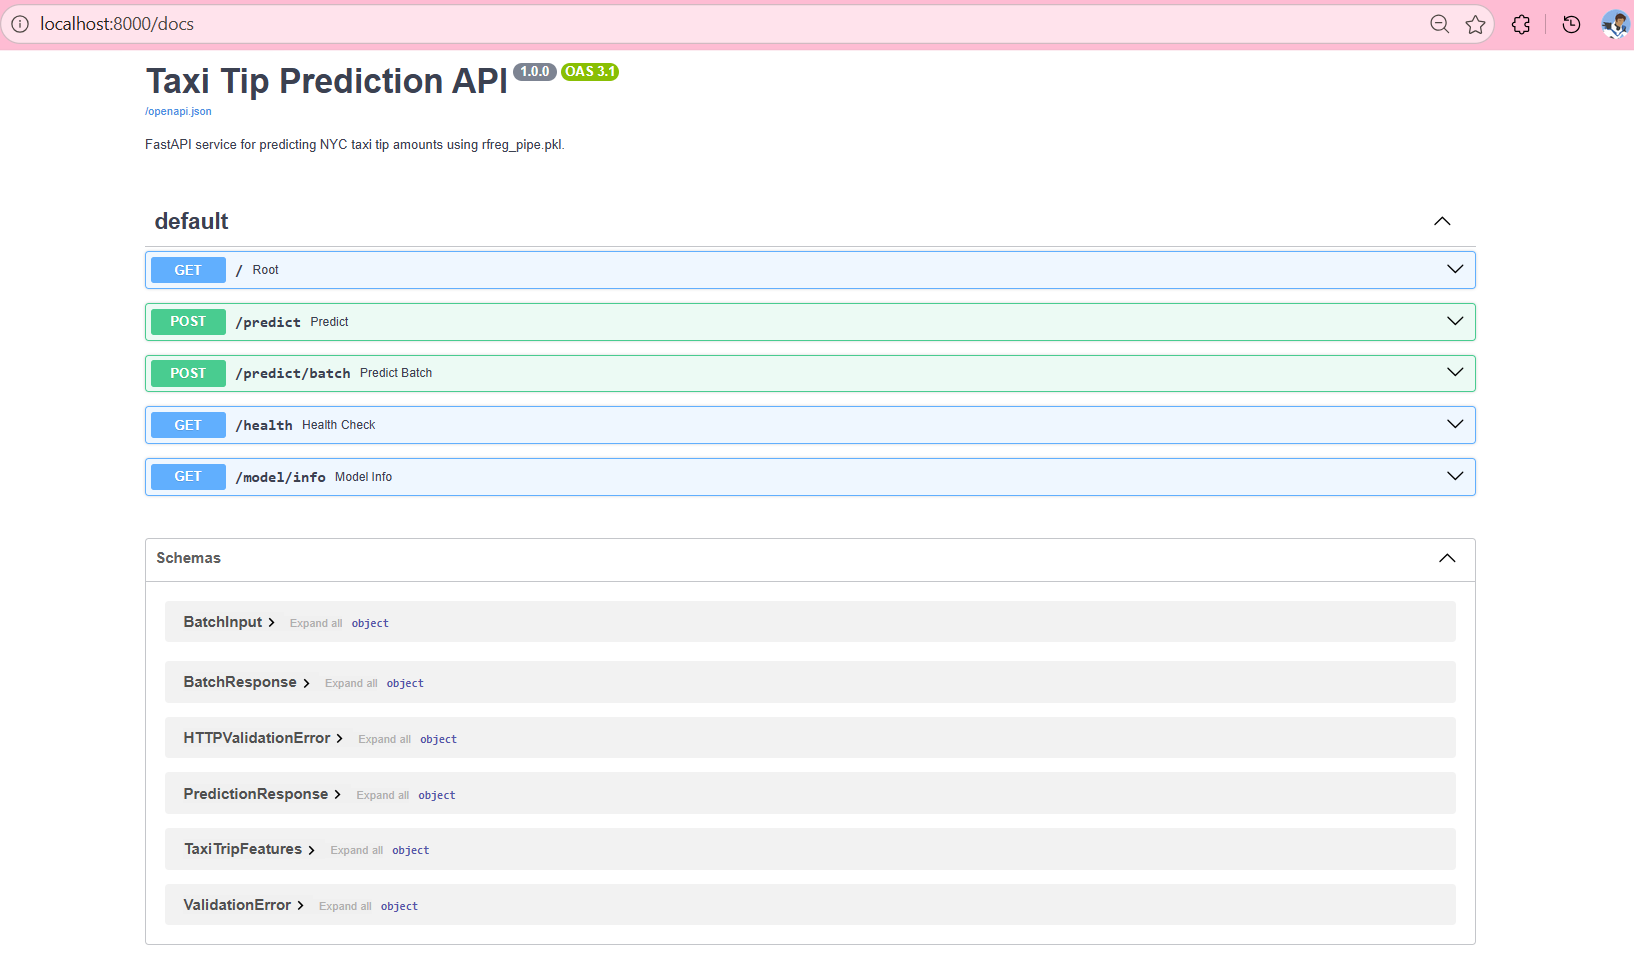

## Screenshot showing /predict endpoint expanded

![Screenshot 2026-04-17 151134.png](<attachment:Screenshot 2026-04-17 151134.png>)
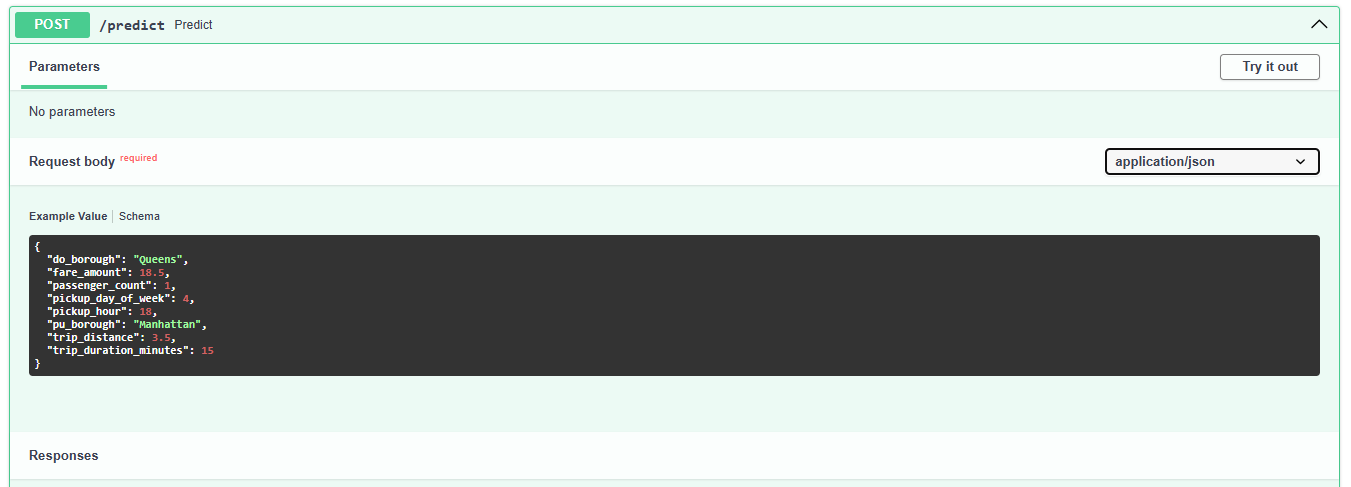

![Screenshot 2026-04-17 151125.png](<attachment:Screenshot 2026-04-17 151125.png>)
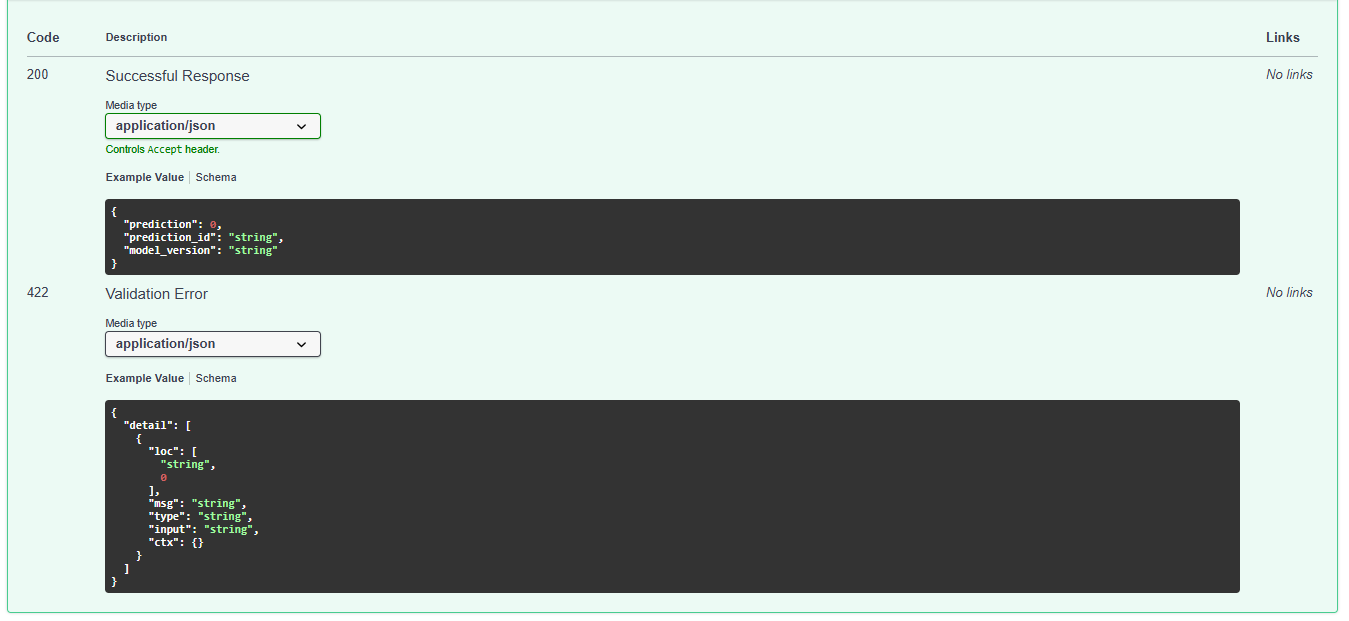

# Part 3: Containerization with Docker

## Terminal showing successful build

![Screenshot 2026-04-17 151503.png](<attachment:Screenshot 2026-04-17 151503.png>)
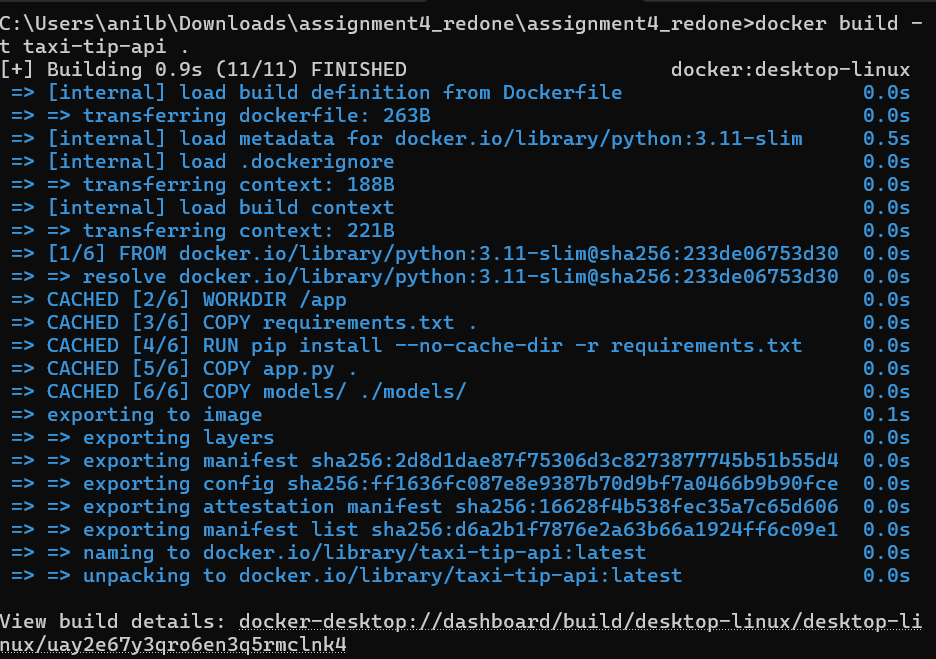

## Terminal showing docker image 

![Screenshot 2026-04-17 152103.png](<attachment:Screenshot 2026-04-17 152103.png>)
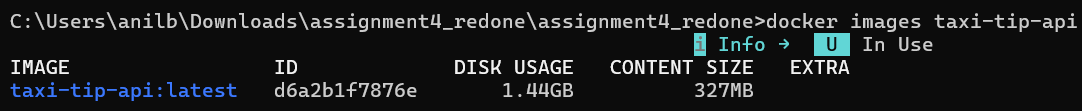

## Terminal showing successful image building "docker compose up -d --build":

![Screenshot 2026-04-17 202102.png](<attachment:Screenshot 2026-04-17 202102.png>)
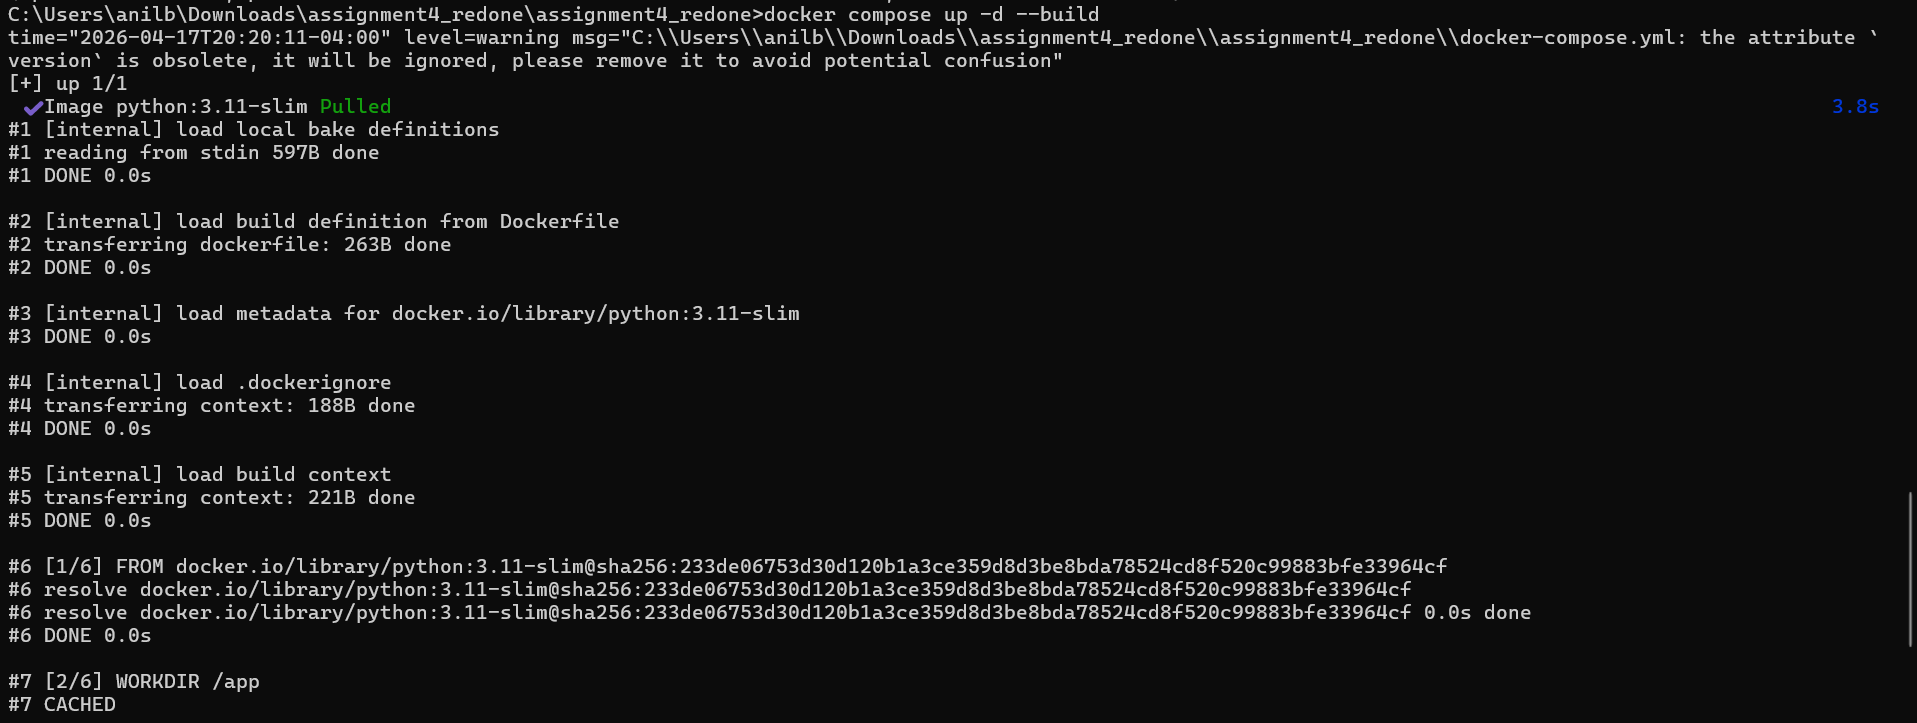

![Screenshot 2026-04-17 202119.png](<attachment:Screenshot 2026-04-17 202119.png>)
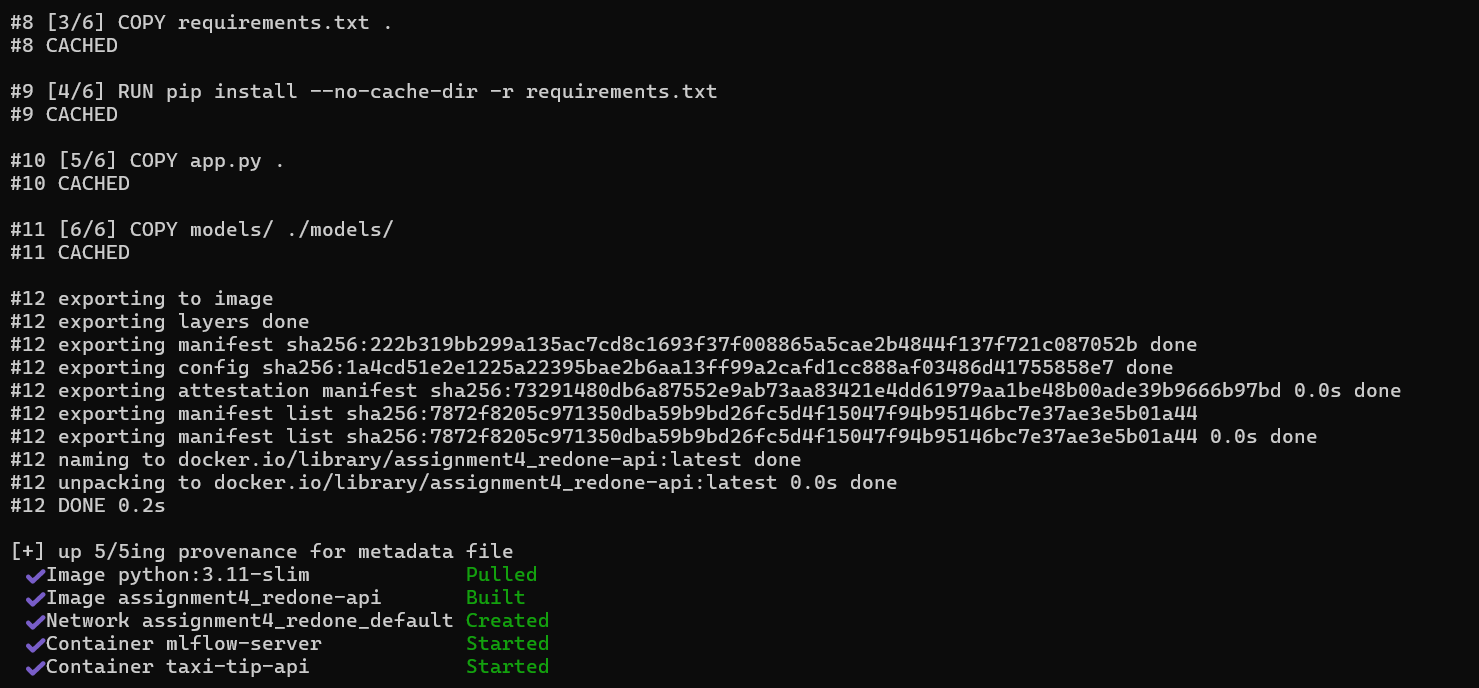

## Terminal showing Docker Health 

![Screenshot 2026-04-17 194244.png](<attachment:Screenshot 2026-04-17 194244.png>)
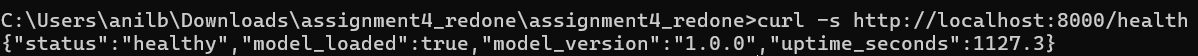

## Terminal showing 3 prediction requests to the containerized API

![Screenshot 2026-04-17 194912.png](<attachment:Screenshot 2026-04-17 194912.png>)
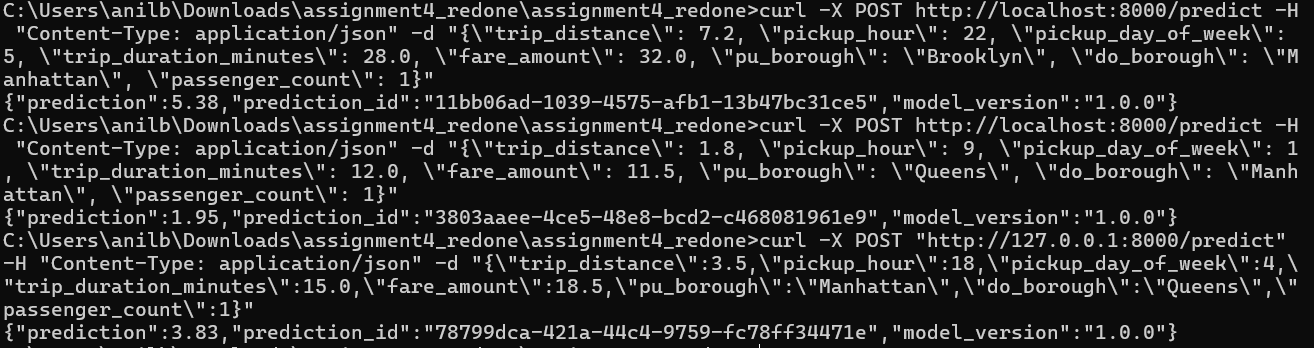

## Terminal showing successful "docker ps"

![Screenshot 2026-04-17 202238.png](<attachment:Screenshot 2026-04-17 202238.png>)
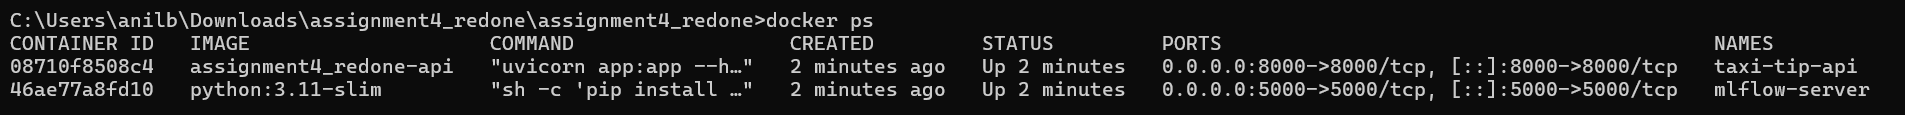

## Terminal showing successful "docker compose down"

![Screenshot 2026-04-17 202353.png](<attachment:Screenshot 2026-04-17 202353.png>)
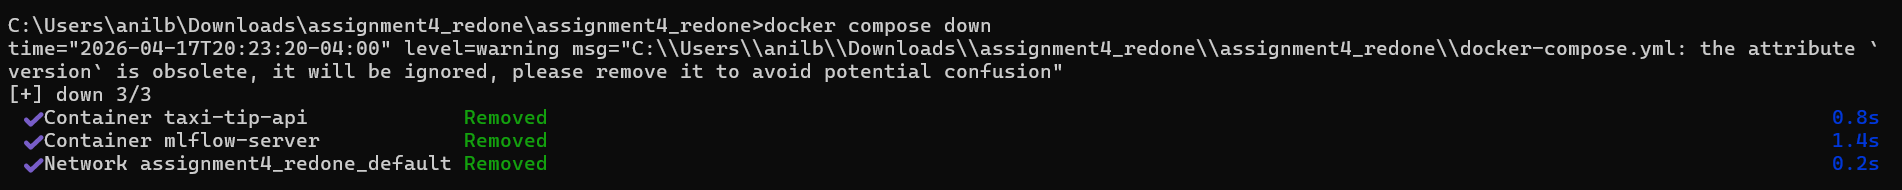

# AI Tools Used

ChatGPT:
- **Code review**:  Reviewing and editing code regarding 'mlflow'.

All final code and analysis reflects the author's own understanding and was verified before submission.